# COHRE Displacement Dataset Exploration
Quick exploration notebook for the housing-impact exploratory visualization.

In [1]:
from pathlib import Path
import pandas as pd

csv_path = Path('data/cohre_displacement_estimates.csv')
csv_path.resolve()

PosixPath('/Users/flo/project1/209 - Data Viz/final-project/data/cohre_displacement_estimates.csv')

In [2]:
df = pd.read_csv(csv_path)
df

,games_year,host_city,country,estimated_displaced_people,estimate_unit,source_short,source_title,notes
0,1988,Seoul,South Korea,720000,people,COHRE 2007,Fair Play for Housing Rights: Mega-Events Olym...,Point estimate reported in COHRE report for Ol...
1,1992,Barcelona,Spain,unknown,people,COHRE 2007,Fair Play for Housing Rights: Mega-Events Olym...,COHRE includes Barcelona discussion; extract e...
2,1996,Atlanta,United States,15000,people,COHRE 2007,Fair Play for Housing Rights: Mega-Events Olym...,Commonly cited estimate; verify against the At...
3,2004,Athens,Greece,unknown,people,COHRE 2007,Fair Play for Housing Rights: Mega-Events Olym...,Extract exact figure from COHRE/Athens backgro...
4,2008,Beijing,China,1500000,people,COHRE 2007,Fair Play for Housing Rights: Mega-Events Olym...,Point estimate commonly cited in COHRE-era sum...
5,2012,London,United Kingdom,unknown,people,COHRE+case studies,Fair Play context and later London case studies,COHRE 2007 predates London 2012; use this row ...
6,2016,Rio de Janeiro,Brazil,22000,families,Comite Popular Rio 2014,Dossie Megaeventos e Violacoes dos Direitos Hu...,Estimate is reported as affected/removed famil...


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   games_year                  7 non-null      int64 
 1   host_city                   7 non-null      object
 2   country                     7 non-null      object
 3   estimated_displaced_people  7 non-null      object
 4   estimate_unit               7 non-null      object
 5   source_short                7 non-null      object
 6   source_title                7 non-null      object
 7   notes                       7 non-null      object
dtypes: int64(1), object(7)
memory usage: 580.0+ bytes


In [4]:
numeric_df = df[pd.to_numeric(df['estimated_displaced_people'], errors='coerce').notna()].copy()
numeric_df['estimated_displaced_people'] = pd.to_numeric(numeric_df['estimated_displaced_people'])
numeric_df.sort_values('estimated_displaced_people', ascending=False)

,games_year,host_city,country,estimated_displaced_people,estimate_unit,source_short,source_title,notes
4,2008,Beijing,China,1500000,people,COHRE 2007,Fair Play for Housing Rights: Mega-Events Olym...,Point estimate commonly cited in COHRE-era sum...
0,1988,Seoul,South Korea,720000,people,COHRE 2007,Fair Play for Housing Rights: Mega-Events Olym...,Point estimate reported in COHRE report for Ol...
6,2016,Rio de Janeiro,Brazil,22000,families,Comite Popular Rio 2014,Dossie Megaeventos e Violacoes dos Direitos Hu...,Estimate is reported as affected/removed famil...
2,1996,Atlanta,United States,15000,people,COHRE 2007,Fair Play for Housing Rights: Mega-Events Olym...,Commonly cited estimate; verify against the At...


Text(0, 0.5, 'Host city')

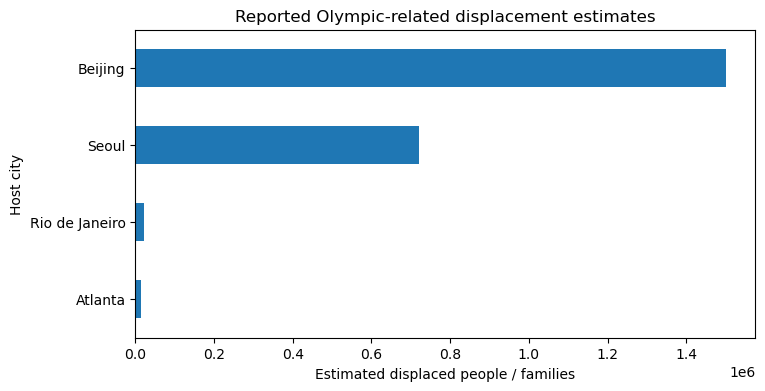

In [5]:
ax = numeric_df.sort_values('estimated_displaced_people').plot(
    kind='barh',
    x='host_city',
    y='estimated_displaced_people',
    legend=False,
    figsize=(8, 4),
    title='Reported Olympic-related displacement estimates'
)
ax.set_xlabel('Estimated displaced people / families')
ax.set_ylabel('Host city')

In [6]:
spine = pd.read_csv('/Users/flo/project1/209 - Data Viz/final-project/data/olympic_housing_event_spine.csv')

In [7]:
spine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   games_year      9 non-null      int64 
 1   bid_award_year  9 non-null      int64 
 2   host_city       9 non-null      object
 3   country         9 non-null      object
 4   event_label     9 non-null      object
dtypes: int64(2), object(3)
memory usage: 492.0+ bytes


In [9]:
spine.head(10)

,games_year,bid_award_year,host_city,country,event_label
0,1988,1981,Seoul,South Korea,Seoul Summer Olympics
1,1992,1986,Barcelona,Spain,Barcelona Summer Olympics
2,1996,1990,Atlanta,United States,Atlanta Summer Olympics
3,2004,1997,Athens,Greece,Athens Summer Olympics
4,2008,2001,Beijing,China,Beijing Summer Olympics
5,2012,2005,London,United Kingdom,London Summer Olympics
6,2016,2009,Rio de Janeiro,Brazil,Rio Summer Olympics
7,2024,2017,Paris,France,Paris Summer Olympics
8,2028,2017,Los Angeles,United States,Los Angeles Summer Olympics
